# Hazard assessment for river flooding — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[FLOODS](https://github.com/CLIMAAX/FLOODS) GitHub repository for Kazakhstan.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| JRC CEMS-EFAS flood maps (`jeodpp.jrc.ec.europa.eu/.../CEMS-EFAS/`) — Europe-only | JRC CEMS-GLOFAS flood maps (`jeodpp.jrc.ec.europa.eu/.../CEMS-GLOFAS/`) — global | EFAS covers only Europe; GLOFAS is the global JRC equivalent using the same methodology |
| Single continental GeoTIFF per return period | Multiple 10°×10° tiles mosaicked to Kazakhstan bbox | GLOFAS distributes globally as tiles; `tile_extents.geojson` is used to identify the relevant ones automatically |
| `EPSG:3035` (EU Lambert Azimuthal Equal Area) | `EPSG:4326` (WGS84 geographic) | EPSG:3035 is Europe-specific and invalid outside Europe |
| NUTS3 / EU administrative regions | Kazakhstan OSM shapefile (oblasts) | EU admin units not applicable outside Europe |
| Aqueduct Floods (RCP4.5, RCP8.5) — future scenarios | Aqueduct Floods (RCP4.5, RCP8.5) — **unchanged** | Already a global dataset; scenario labels match the original CLIMAAX river flood workflow |

**Available return periods in CEMS-GLOFAS:** 10, 20, 50, 75, 100, 200, 500 years.
This workflow uses 10, 50, 100, 200, 500 — matching the original CLIMAAX selection.

## Setup — libraries

In [1]:
import re
import logging
from pathlib import Path

import pooch
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box

logging.getLogger('pooch').setLevel(logging.WARNING)

## Setup — region and bounding box

In [2]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)
OBLAST_FIELD = 'oblast_en'

kaz = gpd.read_file(SHAPEFILE_PATH)

selected_oblast = 'North Kazakhstan Region'

if selected_oblast is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    region_name = re.sub(r'[^a-zA-Z0-9]', '', selected_oblast)
    region_id   = selected_oblast
else:
    region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)
    region_name = 'Kazakhstan'
    region_id   = 'KAZ'

coords_user = gpd.GeoSeries.get_coordinates(region_gdf).to_numpy()

print(f'Region: {region_id}')
print(f'Lon range: [{coords_user[:,0].min():.2f}, {coords_user[:,0].max():.2f}]')
print(f'Lat range: [{coords_user[:,1].min():.2f}, {coords_user[:,1].max():.2f}]')

Region: North Kazakhstan Region
Lon range: [65.96, 74.03]
Lat range: [52.21, 55.44]


In [3]:
bbox = [
    float(coords_user[:,0].min()),
    float(coords_user[:,1].min()),
    float(coords_user[:,0].max()),
    float(coords_user[:,1].max()),
]
print(f'Bounding box: {bbox}')

Bounding box: [65.96311469999995, 52.20696040000013, 74.03496069999994, 55.44217009999994]


## Setup — directory structure

In [4]:
workflow_folder     = Path('.')
general_data_folder = workflow_folder / 'general_data'
glofas_tiles_folder = general_data_folder / 'glofas_tiles'
data_dir            = workflow_folder / f'data_{region_name}'
plot_dir            = workflow_folder / f'plots_{region_name}'

for d in [general_data_folder, glofas_tiles_folder, data_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

## Part 1 — Present-day flood hazard: CEMS-GLOFAS global flood maps

The JRC CEMS-GLOFAS dataset is the global equivalent of the CEMS-EFAS dataset used
in the original CLIMAAX workflow. Both are produced by JRC and share the same
methodology and return period selection. Resolution is ~3 arc-seconds (≈90 m at
Kazakhstan's latitudes).

**Tiling strategy:** GLOFAS distributes data as 10°×10° tiles named
`ID{n}_{lat}_{lon}_RP{rp}_depth.tif`. We first download the published
`tile_extents.geojson` index, use it to identify which tiles intersect the
Kazakhstan bounding box, then download only those tiles and mosaic them.

### Step 1 — Download tile index and identify Kazakhstan tiles

In [5]:
GLOFAS_BASE   = 'https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard'
return_periods = [10, 50, 100, 200, 500]

In [6]:
tile_index_path = general_data_folder / 'tile_extents.geojson'

if not tile_index_path.exists():
    pooch.retrieve(
        url=f'{GLOFAS_BASE}/tile_extents.geojson',
        known_hash=None,
        path=general_data_folder,
        fname='tile_extents.geojson',
    )
    print('Downloaded: tile_extents.geojson')
else:
    print('Cached: tile_extents.geojson')

Cached: tile_extents.geojson


In [7]:
tiles_gdf = gpd.read_file(tile_index_path)
print(f'Total tiles: {len(tiles_gdf)}')
print(f'Columns: {tiles_gdf.columns.tolist()}')
tiles_gdf.head(3)

Total tiles: 271
Columns: ['id', 'name', 'geometry']


,id,name,geometry
0,1,N70_W180,"POLYGON ((-180.00042 70.00207, -170.00125 70.0..."
1,2,N80_W170,"POLYGON ((-170.00125 80.00123, -160.00208 80.0..."
2,3,N70_W170,"POLYGON ((-170.00125 70.00207, -160.00208 70.0..."


In [8]:
kaz_box     = box(*bbox)   
mask      = tiles_gdf.intersects(kaz_box)
kaz_tiles = tiles_gdf[mask].copy()

id_col = [
    c for c in tiles_gdf.columns
    if pd.api.types.is_numeric_dtype(tiles_gdf[c])
    and tiles_gdf[c].between(1, 9999).all()
][0]
kaz_tiles['tile_prefix'] = 'ID' + kaz_tiles[id_col].astype(int).astype(str) + '_' + kaz_tiles['name']
tile_name_col = 'tile_prefix'

print(f'Tiles covering Kazakhstan: {len(kaz_tiles)}')
print(kaz_tiles[['tile_prefix', 'geometry']].to_string())

Tiles covering Kazakhstan: 2
       tile_prefix                                                                                                geometry
174  ID175_N60_E60  POLYGON ((59.97958 60.0029, 69.97875 60.0029, 69.97875 50.00373, 59.97958 50.00373, 59.97958 60.0029))
180  ID181_N60_E70  POLYGON ((69.97875 60.0029, 79.97792 60.0029, 79.97792 50.00373, 69.97875 50.00373, 69.97875 60.0029))


### Step 2 — Download tiles for each return period (skip if cached)

In [9]:
def download_glofas_tile(tile_name, rp, dest_folder):
    fname    = f'{tile_name}_RP{rp}_depth.tif'
    out_path = dest_folder / fname

    if out_path.exists():
        print(f'  Cached: {fname}')
    else:
        url = f'{GLOFAS_BASE}/RP{rp}/{fname}'
        pooch.retrieve(
            url=url,
            known_hash=None,
            path=dest_folder,
            fname=fname,
        )
        print(f'  Downloaded: {fname}')

    return out_path

In [10]:
tile_paths = {}   

for rp in return_periods:
    print(f'\nReturn period RP{rp}:')
    tile_paths[rp] = []
    for tile_name in kaz_tiles[tile_name_col]:
        p = download_glofas_tile(tile_name, rp, glofas_tiles_folder)
        tile_paths[rp].append(p)


Return period RP10:
  Cached: ID175_N60_E60_RP10_depth.tif
  Cached: ID181_N60_E70_RP10_depth.tif

Return period RP50:
  Cached: ID175_N60_E60_RP50_depth.tif
  Cached: ID181_N60_E70_RP50_depth.tif

Return period RP100:
  Cached: ID175_N60_E60_RP100_depth.tif
  Cached: ID181_N60_E70_RP100_depth.tif

Return period RP200:
  Cached: ID175_N60_E60_RP200_depth.tif
  Cached: ID181_N60_E70_RP200_depth.tif

Return period RP500:
  Cached: ID175_N60_E60_RP500_depth.tif
  Cached: ID181_N60_E70_RP500_depth.tif


### Step 3 — Mosaic tiles and clip to Kazakhstan bbox

In [11]:
def load_glofas_rp(tile_file_list, bbox):
    arrays = []
    for f in tile_file_list:
        da = rxr.open_rasterio(f, masked=True)
        arrays.append(da)

    if len(arrays) == 1:
        merged = arrays[0]
    else:
        merged = merge_arrays(arrays)

    clipped = merged.rio.clip_box(*bbox, crs='EPSG:4326')
    clipped = clipped.where(clipped > 0)   
    return clipped

In [12]:
print('Mosaicking and clipping tiles...')
floodmaps = None

for ii, rp in enumerate(return_periods):
    print(f'  RP{rp}...')
    da      = load_glofas_rp(tile_paths[rp], bbox)
    da.name = f'RP{rp}'

    if ii == 0:
        floodmaps = da.to_dataset()
    else:
        floodmaps = xr.merge([floodmaps, da.to_dataset()], combine_attrs='drop_conflicts')

print('Done.')
floodmaps

Mosaicking and clipping tiles...
  RP10...
  RP50...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_33304\3393498781.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps = xr.merge([floodmaps, da.to_dataset()], combine_attrs='drop_conflicts')


  RP100...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_33304\3393498781.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps = xr.merge([floodmaps, da.to_dataset()], combine_attrs='drop_conflicts')


  RP200...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_33304\3393498781.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps = xr.merge([floodmaps, da.to_dataset()], combine_attrs='drop_conflicts')


  RP500...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_33304\3393498781.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps = xr.merge([floodmaps, da.to_dataset()], combine_attrs='drop_conflicts')


Done.


<xarray.Dataset> Size: 753MB
Dimensions:      (x: 9687, y: 3884, band: 1)
Coordinates:
  * x            (x) float64 77kB 65.96 65.96 65.97 65.97 ... 74.03 74.03 74.04
  * y            (y) float64 31kB 55.44 55.44 55.44 55.44 ... 52.21 52.21 52.21
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    RP10         (band, y, x) float32 150MB nan nan nan nan ... nan nan nan nan
    RP50         (band, y, x) float32 150MB nan nan nan nan ... nan nan nan nan
    RP100        (band, y, x) float32 150MB nan nan nan nan ... nan nan nan nan
    RP200        (band, y, x) float32 150MB nan nan nan nan ... nan nan nan nan
    RP500        (band, y, x) float32 150MB nan nan nan nan ... nan nan nan nan

### Step 4 — Visualize present-day flood hazard for selected return periods

In [13]:
print('Maximum inundation depths per return period:')
for rp in return_periods:
    vmax = float(floodmaps[f'RP{rp}'].max())
    print(f'  RP{rp}: {vmax:.2f} m')

Maximum inundation depths per return period:
  RP10: 24.91 m
  RP50: 26.02 m
  RP100: 26.45 m
  RP200: 26.84 m
  RP500: 27.34 m


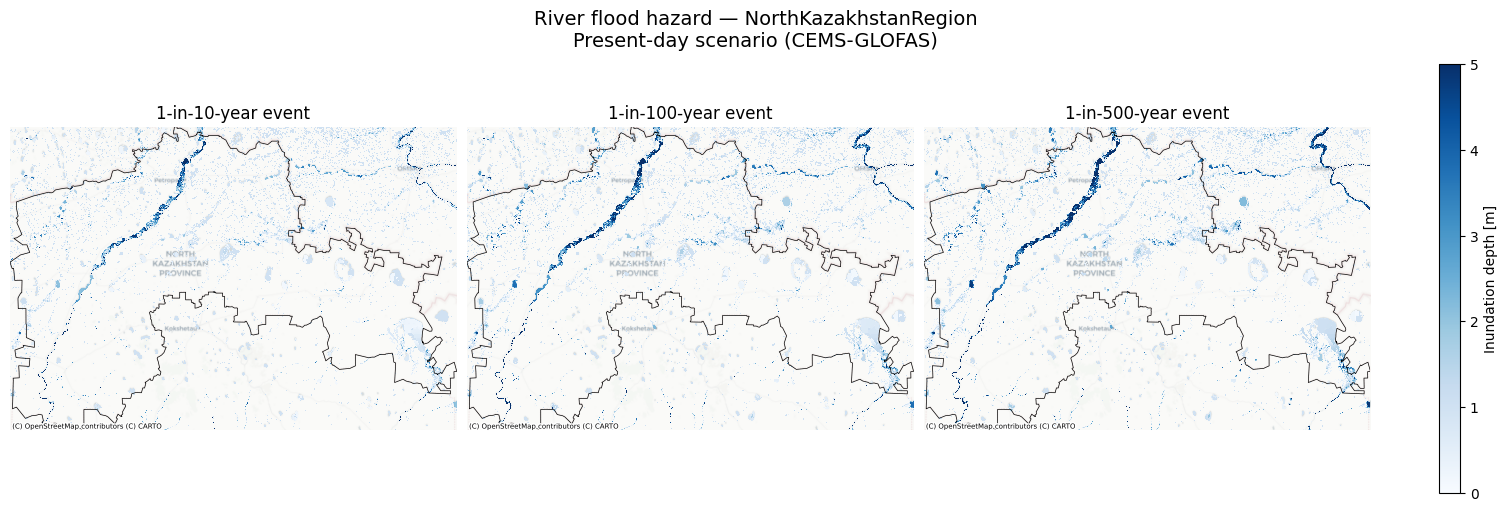

In [14]:
max_inundation = 5   
rps_sel        = [10, 100, 500]

fig, axs = plt.subplots(
    figsize=(15, 5), nrows=1, ncols=3,
    constrained_layout=True, sharex=True, sharey=True,
)

for ii, rp in enumerate(rps_sel):
    step = max(1, int(500 / 90))  
    da_plot = floodmaps[f'RP{rp}'].isel(
        x=slice(None, None, step),
        y=slice(None, None, step),
    )
    bs = da_plot.plot(
        ax=axs[ii], cmap='Blues',
        vmin=0, vmax=max_inundation,
        add_colorbar=False,
    )
    region_gdf.boundary.plot(ax=axs[ii], color='black', linewidth=0.5)
    axs[ii].set_title(f'1-in-{rp}-year event')
    ctx.add_basemap(
        ax=axs[ii], crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron,
        attribution_size=5,
    )
    axs[ii].set_axis_off()

fig.colorbar(bs, ax=axs.ravel().tolist(), orientation='vertical', label='Inundation depth [m]')
fig.suptitle(
    f'River flood hazard — {region_name}\nPresent-day scenario (CEMS-GLOFAS)',
    fontsize=14,
)

fig.savefig(plot_dir / f'Floodmap_overview_GLOFAS_PresentScenario_{region_name}.png', dpi=150)
plt.show()

### Step 5 — Save present-day flood hazard dataset

In [15]:
nc_out = data_dir / f'floodmaps_all_GLOFAS_PresentScenario_{region_name}.nc'
floodmaps.to_netcdf(nc_out)
print(f'Saved: {nc_out}')

Saved: data_NorthKazakhstanRegion\floodmaps_all_GLOFAS_PresentScenario_NorthKazakhstanRegion.nc


In [16]:
for rp in return_periods:
    tif_out = data_dir / f'floodmap_PresentScenario_{region_name}_RP{rp}.tif'
    da = floodmaps[f'RP{rp}'].squeeze()   # remove band dim if present

    da.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
    da.rio.write_crs('EPSG:4326', inplace=True)
    da.rio.to_raster(tif_out)
    print(f'Saved: {tif_out.name}')

Saved: floodmap_PresentScenario_NorthKazakhstanRegion_RP10.tif
Saved: floodmap_PresentScenario_NorthKazakhstanRegion_RP50.tif
Saved: floodmap_PresentScenario_NorthKazakhstanRegion_RP100.tif
Saved: floodmap_PresentScenario_NorthKazakhstanRegion_RP200.tif
Saved: floodmap_PresentScenario_NorthKazakhstanRegion_RP500.tif


## Part 2 — Future flood hazard under climate scenarios: Aqueduct Floods

This section is **unchanged** from the original CLIMAAX workflow. The WRI Aqueduct
Floods dataset is already global and uses RCP4.5 / RCP8.5 scenarios — the same
scenario labels used in the original river flood workflow. No substitution is needed.

Coarse resolution (~1 km / 30 arc-seconds) is noted as a limitation in both the
original workflow and here. Results are qualitative indicators of climate change
direction, not high-resolution flood maps.

Models: NorESM1-M, GFDL-ESM2M, HadGEM2-ES, IPSL-CM5A-LR, MIROC-ESM-CHEM
Time horizons: 2030, 2050, 2080
Scenarios: RCP4.5, RCP8.5
Return period used for scenario comparison: 250 years

In [17]:
return_period_aq = 250  

data_dir_aqueduct = data_dir / 'aqueduct_floods'
data_dir_aqueduct.mkdir(exist_ok=True)

### Step 6 — Load Aqueduct baseline (ca. 1980)

In [18]:
aq_fname_base = f'inunriver_historical_000000000WATCH_1980_rp{return_period_aq:05}.tif'
aq_path_base  = general_data_folder / aq_fname_base
aq_out_base   = data_dir_aqueduct / aq_fname_base.replace('.tif', f'_{region_name}.nc')

if not aq_out_base.exists():
    if not aq_path_base.exists():
        url = f'http://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/{aq_fname_base}'
        pooch.retrieve(url=url, known_hash=None, path=general_data_folder, fname=aq_fname_base)
        print(f'Downloaded: {aq_fname_base}')
    else:
        print(f'Cached: {aq_fname_base}')

    with rxr.open_rasterio(aq_path_base) as ds:
        aq_base = ds.rio.clip_box(*bbox, crs=ds.rio.crs)
        aq_base = aq_base.where(aq_base > 0)
        aq_base.name = 'inun'
        aq_base = aq_base.assign_coords(year=1980).expand_dims('year')
        aq_base = aq_base.assign_coords(scenario='baseline').expand_dims('scenario')
        aq_base = aq_base.to_dataset()
        aq_base.to_netcdf(aq_out_base)

    if aq_path_base.exists():
        aq_path_base.unlink()
    print(f'Saved clipped baseline: {aq_out_base.name}')
else:
    aq_base = xr.open_dataset(aq_out_base)
    print(f'Cached: {aq_out_base.name}')

Cached: inunriver_historical_000000000WATCH_1980_rp00250_NorthKazakhstanRegion.nc


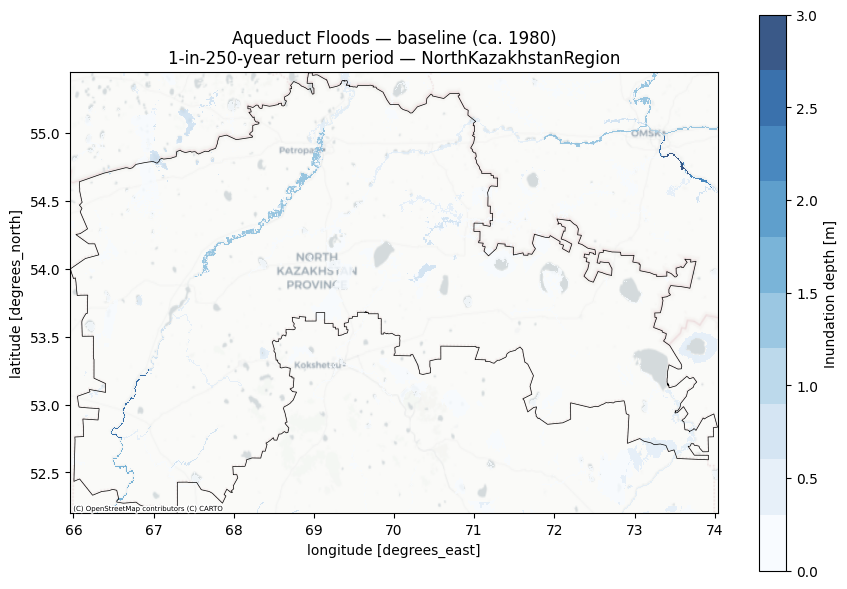

In [19]:
cmap_flood = plt.get_cmap('Blues', 10)
fig, ax = plt.subplots(figsize=(9, 6))
aq_base['inun'].plot(
    ax=ax, cmap=cmap_flood, alpha=0.8,
    vmin=0, vmax=np.ceil(float(aq_base['inun'].max())),
    cbar_kwargs={'label': 'Inundation depth [m]'},
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
ctx.add_basemap(ax=ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=5)
ax.set_title(
    f'Aqueduct Floods — baseline (ca. 1980)\n'
    f'1-in-{return_period_aq}-year return period — {region_name}',
)
plt.tight_layout()
fig.savefig(plot_dir / f'Floodmap_Aqueduct_baseline_{region_name}.png', dpi=150)
plt.show()

### Step 7 — Download all Aqueduct future scenario tiles (skip if cached)

In [20]:
models    = ['NorESM1-M', 'GFDL-ESM2M', 'HadGEM2-ES', 'IPSL-CM5A-LR', 'MIROC-ESM-CHEM']
years     = [2030, 2050, 2080]
scenarios = ['rcp4p5', 'rcp8p5']

for scenario in scenarios:
    for year in years:
        for model in models:
            aq_fname  = f'inunriver_{scenario}_{model.rjust(14,"0")}_{year}_rp{return_period_aq:05}.tif'
            aq_path   = general_data_folder / aq_fname
            aq_out    = data_dir_aqueduct / aq_fname.replace('.tif', f'_{region_name}.nc')

            if aq_out.exists():
                print(f'Cached: {aq_out.name}')
                continue

            if not aq_path.exists():
                url = f'http://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/{aq_fname}'
                pooch.retrieve(url=url, known_hash=None, path=general_data_folder, fname=aq_fname)
                print(f'Downloaded: {aq_fname}')

            with rxr.open_rasterio(aq_path) as ds:
                aq_local = ds.rio.clip_box(*bbox, crs=ds.rio.crs)
                aq_local.load()
                aq_local = aq_local.where(aq_local > 0)
                aq_local.name = 'inun'
                aq_local = aq_local.assign_coords(year=year).expand_dims('year')
                aq_local = aq_local.assign_coords(scenario=scenario).expand_dims('scenario')
                aq_local = aq_local.assign_coords(model=model).expand_dims('model')
                aq_local = aq_local.to_dataset()
                aq_local.to_netcdf(aq_out)

            if aq_path.exists():
                aq_path.unlink()   # remove global tile to save space

Cached: inunriver_rcp4p5_00000NorESM1-M_2030_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000GFDL-ESM2M_2030_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000HadGEM2-ES_2030_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_00IPSL-CM5A-LR_2030_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_MIROC-ESM-CHEM_2030_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_00000NorESM1-M_2050_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000GFDL-ESM2M_2050_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000HadGEM2-ES_2050_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_00IPSL-CM5A-LR_2050_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_MIROC-ESM-CHEM_2050_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_00000NorESM1-M_2080_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000GFDL-ESM2M_2080_rp00250_NorthKazakhstanRegion.nc
Cached: inunriver_rcp4p5_0000HadGEM2-ES_2080_rp00250_NorthKazakh

### Step 8 — Average over models and save combined dataset

In [21]:
from collections import defaultdict

groups = defaultdict(list)

for sc in scenarios:
    for y in years:
        for m in models:
            nc = (
                data_dir_aqueduct
                / f'inunriver_{sc}_{m.rjust(14,"0")}_{y}_rp{return_period_aq:05}_{region_name}.nc'
            )
            da = xr.open_dataset(nc)['inun'].squeeze()
            groups[(sc, y)].append(da)

scenario_arrays = []
for sc in scenarios:
    year_arrays = []
    for y in years:
        stacked  = xr.concat(groups[(sc, y)], dim='model').assign_coords(model=models)
        mean_da  = stacked.mean(dim='model')
        mean_da  = mean_da.assign_coords(year=y).expand_dims('year')
        year_arrays.append(mean_da)
    sc_da = xr.concat(year_arrays, dim='year')
    sc_da = sc_da.assign_coords(scenario=sc).expand_dims('scenario')
    scenario_arrays.append(sc_da)

aq_mean      = xr.concat(scenario_arrays, dim='scenario').to_dataset(name='inun')
aq_mean_path = (
    data_dir_aqueduct
    / f'inunriver_AllScenarios_AllModels_AllYears_rp{return_period_aq:05}_{region_name}.nc'
)
aq_mean.to_netcdf(aq_mean_path)
print(f'Saved model-mean dataset: {aq_mean_path.name}')

Saved model-mean dataset: inunriver_AllScenarios_AllModels_AllYears_rp00250_NorthKazakhstanRegion.nc


### Step 9 — Compare flood maps under future climate scenarios

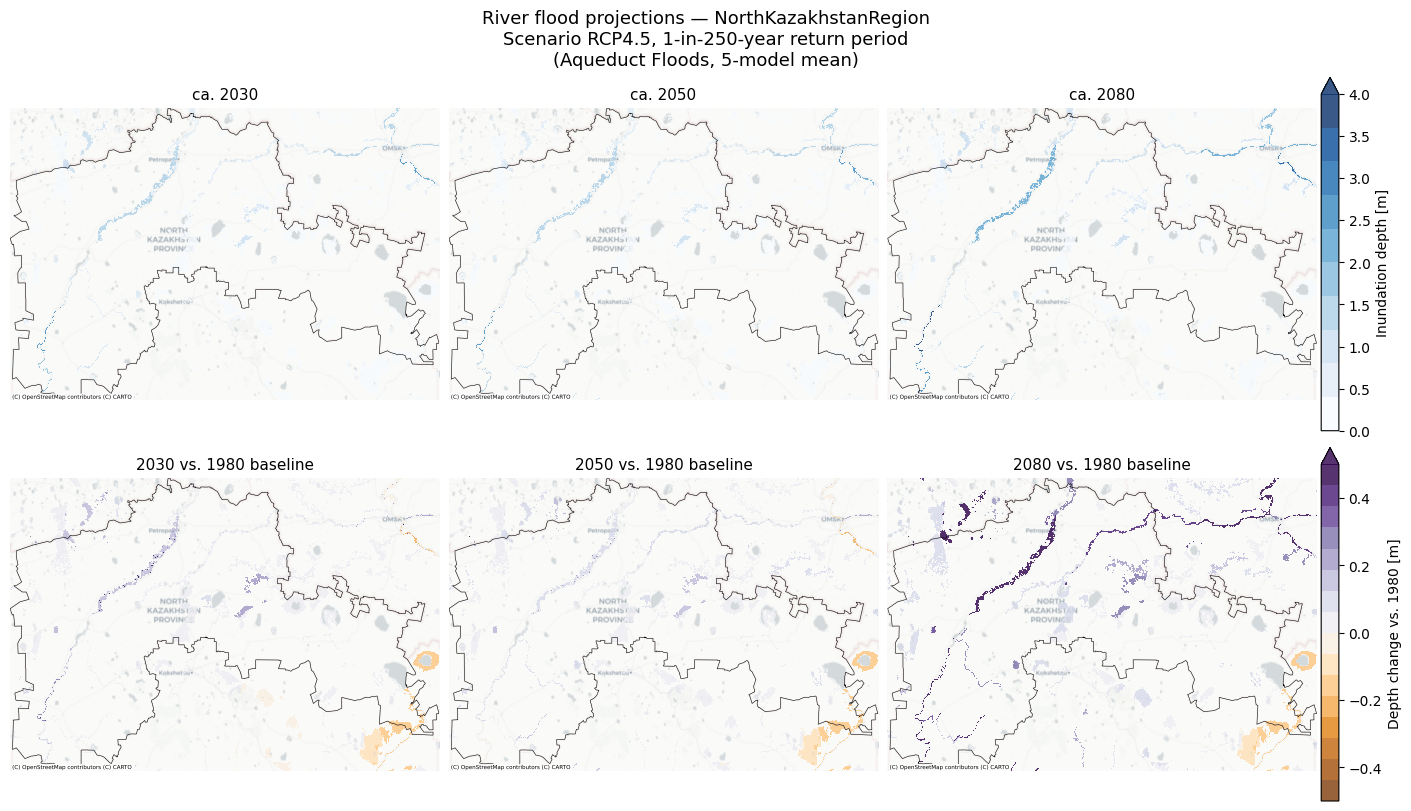

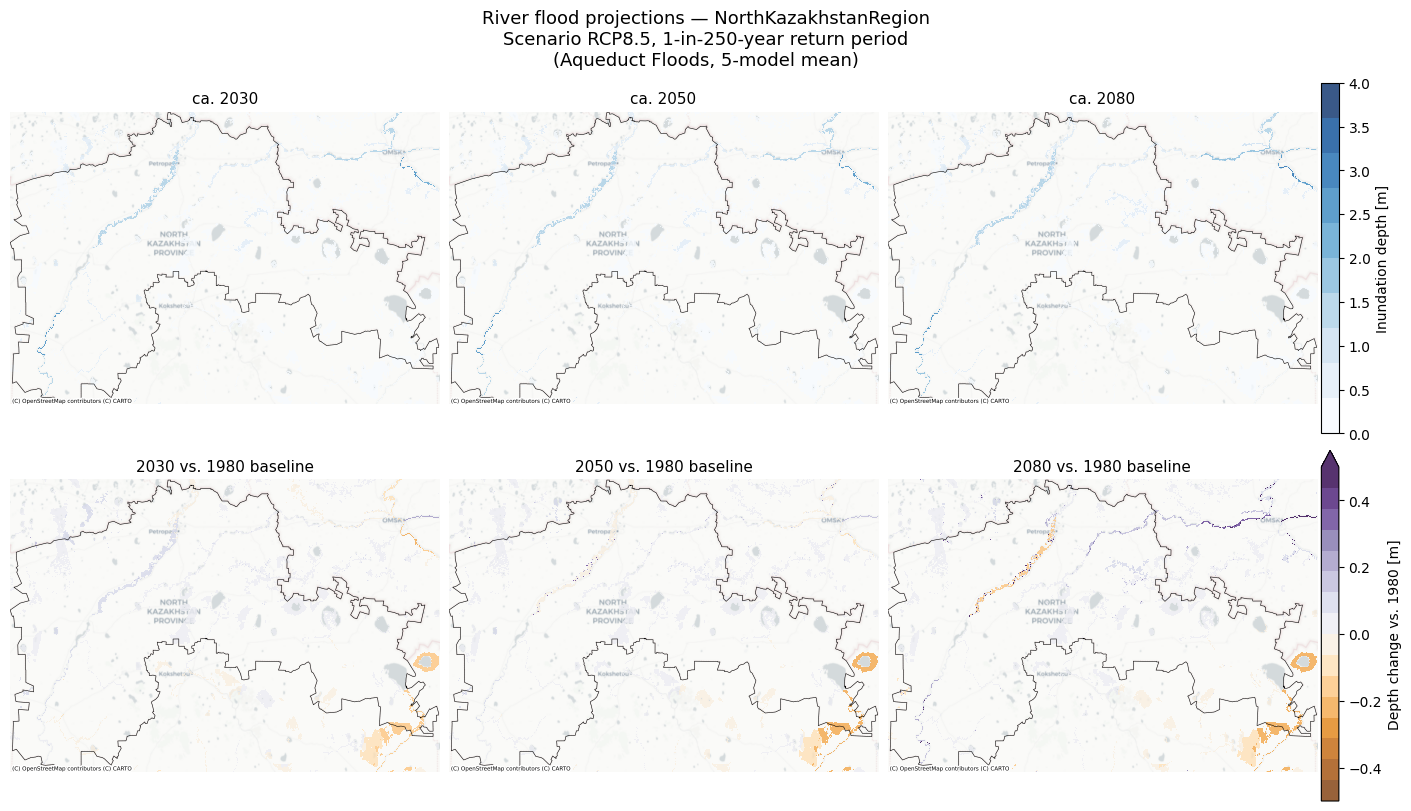

In [22]:
cmap_flood = plt.get_cmap('Blues', 10)
cmap_diff  = plt.get_cmap('PuOr', 16)

aq_base  = xr.open_dataset(aq_out_base)
aq_all   = xr.open_dataset(aq_mean_path)

vmax_abs  = float(np.ceil(aq_all['inun'].sel(year=years[-1], scenario=scenarios[-1]).max()))
lims_diff = [-0.5, 0.5]

for scenario in scenarios:
    fig, axs = plt.subplots(
        figsize=(14, 8), nrows=2, ncols=3,
        sharex=True, sharey=True, constrained_layout=True,
    )
    scen_label = scenario.upper().replace('P5', '.5')   # rcp4p5 → RCP4.5
    fig.suptitle(
        f'River flood projections — {region_name}\n'
        f'Scenario {scen_label}, 1-in-{return_period_aq}-year return period\n'
        f'(Aqueduct Floods, 5-model mean)',
        fontsize=13,
    )

    for jj, year in enumerate(years):
        da_scen = aq_all['inun'].sel(year=year, scenario=scenario)
        da_diff = da_scen - aq_base['inun'].squeeze()

        add_cbar_top  = (jj == len(years) - 1)
        add_cbar_bot  = (jj == len(years) - 1)

        da_scen.plot(
            ax=axs[0, jj], cmap=cmap_flood, alpha=0.8,
            vmin=0, vmax=vmax_abs,
            add_colorbar=add_cbar_top,
            cbar_kwargs={'label': 'Inundation depth [m]', 'pad': 0.01, 'aspect': 20} if add_cbar_top else {},
        )
        region_gdf.boundary.plot(ax=axs[0, jj], color='black', linewidth=0.4)
        ctx.add_basemap(axs[0, jj], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
        axs[0, jj].set_title(f'ca. {year}', fontsize=11)
        axs[0, jj].set_axis_off()

        da_diff.plot(
            ax=axs[1, jj], cmap=cmap_diff, alpha=0.8,
            vmin=lims_diff[0], vmax=lims_diff[1],
            add_colorbar=add_cbar_bot,
            cbar_kwargs={'label': 'Depth change vs. 1980 [m]', 'pad': 0.01, 'aspect': 20} if add_cbar_bot else {},
        )
        region_gdf.boundary.plot(ax=axs[1, jj], color='black', linewidth=0.4)
        ctx.add_basemap(axs[1, jj], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
        axs[1, jj].set_title(f'{year} vs. 1980 baseline', fontsize=11)
        axs[1, jj].set_axis_off()

    fig.savefig(
        plot_dir / f'Floodmaps_Aqueduct_{region_name}_{scen_label.replace(".","")}.png',
        dpi=150,
    )
    plt.show()

## Conclusions

This hazard workflow demonstrated:

- How to retrieve the JRC CEMS-GLOFAS global flood maps for Kazakhstan by
  automatically identifying the relevant 10°×10° tiles from the published tile
  index, mosaicking them, and clipping to the Kazakhstan bounding box.
- How to interpret river flood maps for different return periods under the
  present-day scenario (CEMS-GLOFAS, ~90 m resolution).
- How to retrieve and compare the WRI Aqueduct Floods coarse-resolution
  (~1 km) flood maps for Kazakhstan under RCP4.5 and RCP8.5 climate scenarios
  (2030, 2050, 2080) relative to the 1980 baseline.

**Kazakhstan-specific notes:**
- The Irtysh, Syr Darya, Ural, Ili, and Tobol river systems are the primary
  flood-prone river networks and should show the most prominent flood extents.
- The Aqueduct dataset was built for global application and carries substantial
  uncertainty at the national scale. Results should be treated as qualitative
  indicators of climate change direction rather than precise local flood depths.
- The GLOFAS dataset only includes river basins > 150 km²; smaller watercourses
  in mountainous areas (e.g. Tian Shan foothills) will not appear.
- These flood hazard maps are the input for the river flood risk workflow
  (exposure × vulnerability).